In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

In [ ]:
# 载入数据集
iris = datasets.load_iris()
X, y = iris.data, iris.target
target_names = iris.target_names

# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

'''
数据标准化
如果某个特征的数值范围远大于其他特征（比如一个特征在 [0, 1000]，另一个在 [0, 1]）,
那么距离计算会被大数值特征主导，小数值特征几乎不起作用
'''

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 训练 SVM 模型
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

# C是惩罚参数。C越大，模型对误分类的惩罚越重，倾向于减少训练错误（可能过拟合）；C越小，允许更多训练错误，但决策边界更平滑。
# 'scale'的意思是 gamma = 1 / (n_features * X.var())，是sklearn的推荐设置

svm.fit(X_train_scaled, y_train)
y_pred = svm.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)   # 展示神力
print(f"Test accuracy (full features): {accuracy:.2%}")


Test accuracy (full features): 93.33%


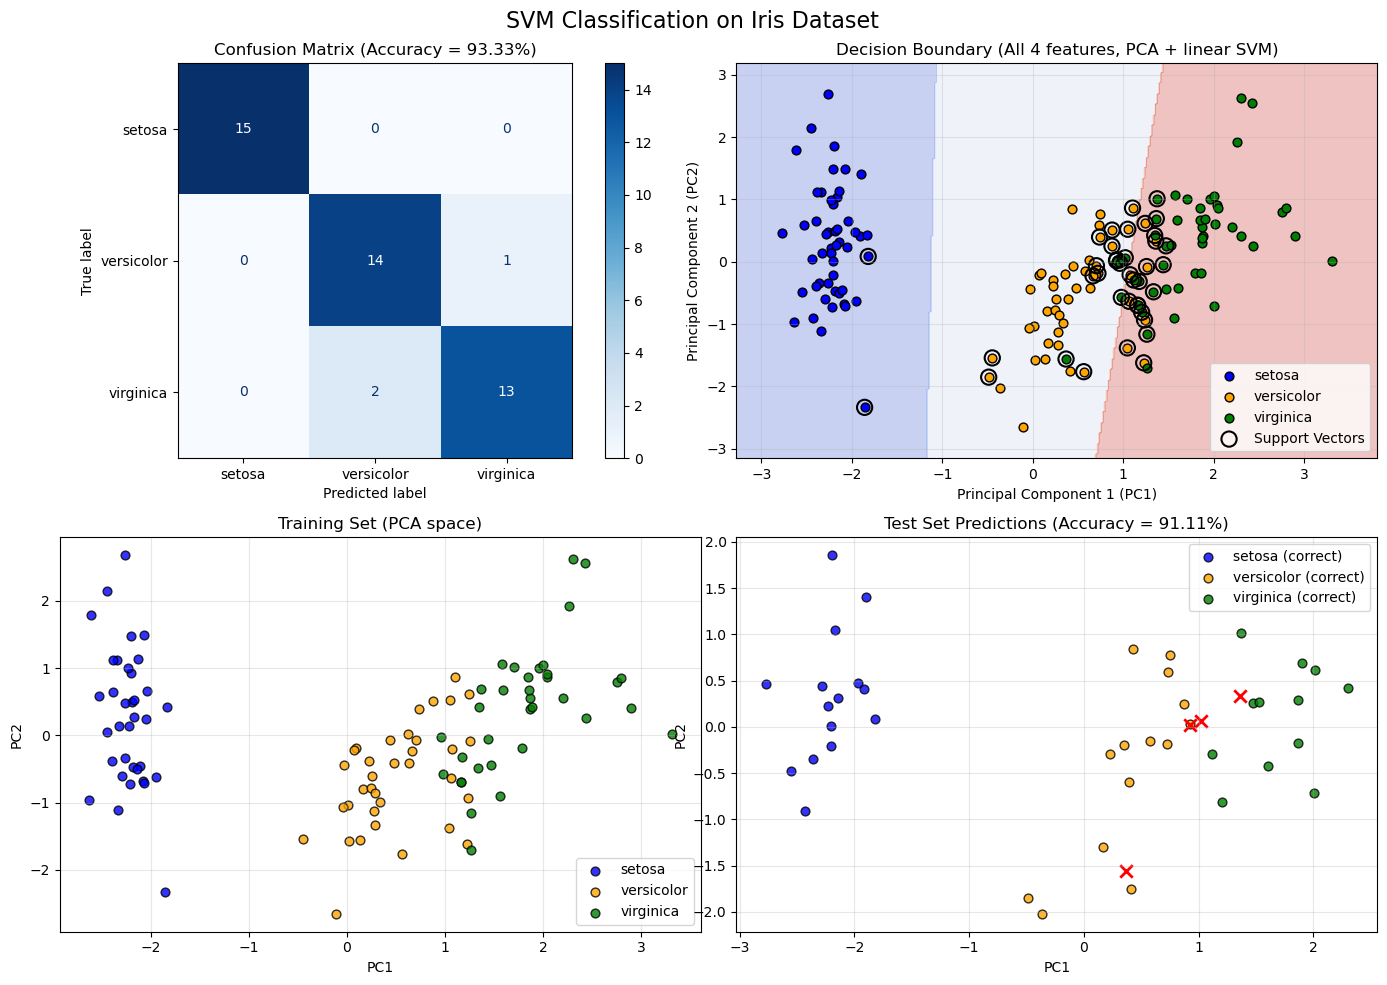

In [ ]:
# 可视化部分

# 准备 PCA 降维后的数据（用于后续可视化）
X_scaled = scaler.fit_transform(X)          # 标准化全部数据
pca = PCA(n_components=2, random_state=42)
X_pca_all = pca.fit_transform(X_scaled)     # 降维后的全部数据 (150,2)

# 在 PCA 空间训练线性 SVM（用于绘制决策边界）
svm_pca_boundary = SVC(kernel='linear', C=1.0, random_state=42)
svm_pca_boundary.fit(X_pca_all, y)

# 用于第三部分：重新划分训练/测试集（基于 PCA 后的数据）
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca_all, y, test_size=0.3, random_state=42, stratify=y
)
svm_pca = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_pca.fit(X_train_pca, y_train_pca)
y_pred_pca = svm_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test_pca, y_pred_pca)


fig = plt.figure(figsize=(14, 10))
# 使用 GridSpec 精细控制布局
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1])

# 左上：混淆矩阵
ax_cm = fig.add_subplot(gs[0, 0])
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                         display_labels=target_names,
                                         cmap='Blues', ax=ax_cm)
ax_cm.set_title(f'Confusion Matrix (Accuracy = {accuracy:.2%})', fontsize=12)

# 右上：决策边界
ax_boundary = fig.add_subplot(gs[0, 1])

x_min, x_max = X_pca_all[:, 0].min() - 0.5, X_pca_all[:, 0].max() + 0.5
y_min, y_max = X_pca_all[:, 1].min() - 0.5, X_pca_all[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = svm_pca_boundary.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 绘制决策区域
ax_boundary.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
colors = ['blue', 'orange', 'green']
# 绘制所有样本点（PCA 空间）
for i, name in enumerate(target_names):
    mask = (y == i)
    ax_boundary.scatter(X_pca_all[mask, 0], X_pca_all[mask, 1],
                        c=colors[i], label=name, edgecolors='k', s=40)
# 标记支持向量
sv_idx = svm_pca_boundary.support_
ax_boundary.scatter(X_pca_all[sv_idx, 0], X_pca_all[sv_idx, 1],
                    s=120, facecolors='none', edgecolors='k', linewidth=1.5,
                    label='Support Vectors')
ax_boundary.set_xlabel('Principal Component 1 (PC1)')
ax_boundary.set_ylabel('Principal Component 2 (PC2)')
ax_boundary.set_title('Decision Boundary (All 4 features, PCA + linear SVM)')
ax_boundary.legend()
ax_boundary.grid(alpha=0.3)

# 下方：PCA 降维后训练/测试集分类效果
gs_sub = gs[1, :].subgridspec(1, 2)   # 将下边一整行分为两列
ax_train = fig.add_subplot(gs_sub[0, 0])
ax_test = fig.add_subplot(gs_sub[0, 1])

# 左：训练集分布
for i, name in enumerate(target_names):
    mask = (y_train_pca == i)
    ax_train.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
                     c=colors[i], label=name, edgecolors='k', s=40, alpha=0.8)
ax_train.set_xlabel('PC1')
ax_train.set_ylabel('PC2')
ax_train.set_title(f'Training Set (PCA space)')
ax_train.legend()
ax_train.grid(alpha=0.3)

# 右：测试集预测结果（正确/错误标记）
for i, name in enumerate(target_names):
    mask_correct = (y_test_pca == i) & (y_pred_pca == i)
    mask_error = (y_test_pca == i) & (y_pred_pca != i)
    ax_test.scatter(X_test_pca[mask_correct, 0], X_test_pca[mask_correct, 1],
                    c=colors[i], label=f'{name} (correct)', edgecolors='k', s=40, alpha=0.8)
    if np.any(mask_error):
        ax_test.scatter(X_test_pca[mask_error, 0], X_test_pca[mask_error, 1],
                        marker='x', c='red', s=80, linewidths=2,
                        label=f'{name} (error)' if i == 0 else '')
ax_test.set_xlabel('PC1')
ax_test.set_ylabel('PC2')
ax_test.set_title(f'Test Set Predictions (Accuracy = {acc_pca:.2%})')
ax_test.legend(loc='best')
ax_test.grid(alpha=0.3)

# 整体大图标题
fig.suptitle('SVM Classification on Iris Dataset', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()